## 1. 라이브러리 임포트 및 설정

In [16]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
import os
import random
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

# 재현성을 위한 시드 설정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 설정
FONT_PATHS = glob('../assets/*.ttf', recursive=True)
IMAGE_SIZE = (28, 28)
BASE_FONT_SIZE = 25

# 무지개 색상 팔레트 정의 (7가지 색상)
RAINBOW_COLORS = [
    (255, 0, 0),    # 빨강
    (255, 127, 0),  # 주황
    (255, 255, 0),  # 노랑  
    (0, 255, 0),    # 초록
    (0, 0, 255),    # 파랑
    (75, 0, 130),   # 남색 (인디고)
    (148, 0, 211)   # 보라
]

RAINBOW_NAMES = [
    'RED',
    'ORANGE',
    'YELLOW',
    'GREEN',
    'BLUE',
    'INDIGO',
    'VIOLET'
]

print(f"{len(FONT_PATHS)}개의 폰트 파일을 찾았습니다")
if FONT_PATHS:
    print(f"샘플 폰트: {os.path.basename(FONT_PATHS[0])}")
print(f"색상 팔레트: {len(RAINBOW_COLORS)}가지 색상")

5개의 폰트 파일을 찾았습니다
샘플 폰트: MaruBuri-Bold.ttf
색상 팔레트: 7가지 색상


## 2. 데이터 증강 파라미터 설정

**각 증강 강도를 조절하려면 아래 파라미터를 조정하세요:**

In [17]:
# ============================================================
# 데이터 증강 범위 설정
# ============================================================
# 각 증강의 강도를 조절하려면 아래 값들을 수정하세요

# 1. 회전 범위 (도)
ROTATION_RANGE = (-20, 20)  # 최소 및 최대 회전 각도

# 2. 폰트 크기 범위
FONT_SIZE_RANGE = (20, 30)  # 최소 및 최대 폰트 크기

# 3. 위치 오프셋 범위
POSITION_X_RANGE = (-8, 8)  # 수평 오프셋 (픽셀) , 경계값 : -7, 7
POSITION_Y_RANGE = (-6, 6)  # 수직 오프셋 (픽셀) , 경계값 : -12 , 0

# 4. 블러 범위
BLUR_RADIUS_RANGE = (0, 0.8)  # 가우시안 블러 반경 (0 = 블러 없음)

# 5. 데이터셋 생성
VARIATIONS_PER_DIGIT = 100  # 숫자당 폰트당 변형 개수

# ============================================================
# 현재 설정 표시
# ============================================================
print("현재 데이터 증강 설정:")
print("=" * 50)
print(f"회전 범위:       {ROTATION_RANGE[0]}° ~ {ROTATION_RANGE[1]}°")
print(f"폰트 크기 범위:   {FONT_SIZE_RANGE[0]} ~ {FONT_SIZE_RANGE[1]}")
print(f"위치 X 범위:     {POSITION_X_RANGE[0]} ~ {POSITION_X_RANGE[1]} 픽셀")
print(f"위치 Y 범위:     {POSITION_Y_RANGE[0]} ~ {POSITION_Y_RANGE[1]} 픽셀")
print(f"블러 반경 범위:   {BLUR_RADIUS_RANGE[0]} ~ {BLUR_RADIUS_RANGE[1]}")
print(f"숫자당 변형 개수: {VARIATIONS_PER_DIGIT}")
print("=" * 50)

현재 데이터 증강 설정:
회전 범위:       -20° ~ 20°
폰트 크기 범위:   20 ~ 30
위치 X 범위:     -8 ~ 8 픽셀
위치 Y 범위:     -6 ~ 6 픽셀
블러 반경 범위:   0 ~ 0.8
숫자당 변형 개수: 100


## 2. 기본 함수 - 단순 숫자 이미지 생성

In [18]:
def generate_base_digit(digit, font_path, font_size=25, canvas_size=(28, 28)):
    """
    증강 없이 기본 숫자 이미지를 생성합니다.
    
    Args:
        digit (int): 생성할 숫자 (0-9)
        font_path (str): 폰트 파일 경로
        font_size (int): 폰트 크기
        canvas_size (tuple): 이미지 크기
    
    Returns:
        PIL.Image: 생성된 이미지
    """
    image = Image.new("L", canvas_size, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        print(f"폰트 로드 실패: {font_path}")
        return None
    
    # 텍스트 위치 계산 (중앙 정렬)
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # 위치: 수평 중앙, 수직으로 -3 오프셋으로 상단에 배치
    position = (
        (canvas_size[0] - text_width) // 2,
        -3
    )
    
    draw.text(position, str(digit), fill=0, font=font)
    
    return image

## 3. 증강 함수 1: 회전

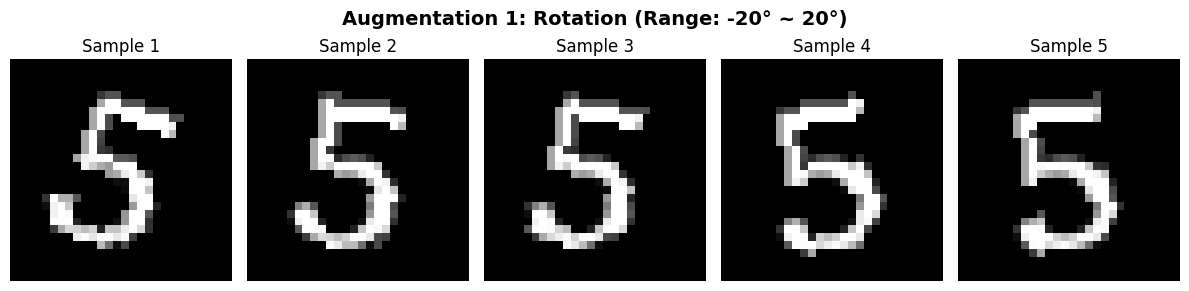

In [19]:
def apply_rotation(image, angle_range=(-20, 20)):
    """
    이미지에 랜덤 회전을 적용합니다.
    
    Args:
        image (PIL.Image): 입력 이미지
        angle_range (tuple): 최소 및 최대 회전 각도 (도 단위)
    
    Returns:
        PIL.Image: 회전된 이미지
    """
    angle = random.uniform(*angle_range)
    rotated = image.rotate(angle, fillcolor=255, expand=False)
    return rotated

# 시각화
if FONT_PATHS:
    test_digit = 5
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 1: Rotation (Range: {ROTATION_RANGE[0]}° ~ {ROTATION_RANGE[1]}°)', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes):
        base_img = generate_base_digit(test_digit, test_font)
        if base_img:
            rotated_img = apply_rotation(base_img, angle_range=ROTATION_RANGE)
            # 표시를 위해 반전
            img_array = 255 - np.array(rotated_img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Sample {i+1}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. 증강 함수 2: 블러 (엣지 대비)

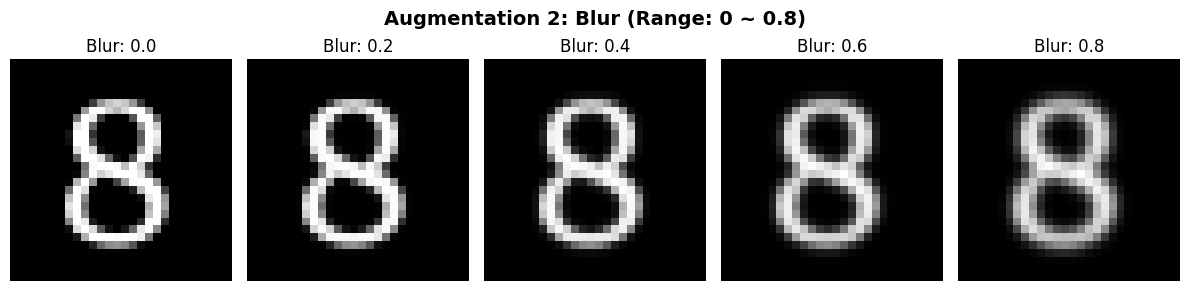

In [20]:
def apply_blur(image, blur_range=(0, 1.0)):
    """
    가우시안 블러를 적용하여 엣지를 부드럽게 만듭니다.
    
    Args:
        image (PIL.Image): 입력 이미지
        blur_range (tuple): 최소 및 최대 블러 반경
    
    Returns:
        PIL.Image: 블러 처리된 이미지
    """
    blur_radius = random.uniform(*blur_range)
    if blur_radius > 0.1:
        blurred = image.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return blurred
    return image

# 시각화
if FONT_PATHS:
    test_digit = 8
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 2: Blur (Range: {BLUR_RADIUS_RANGE[0]} ~ {BLUR_RADIUS_RANGE[1]})', 
                 fontsize=14, fontweight='bold')
    
    blur_values = np.linspace(BLUR_RADIUS_RANGE[0], BLUR_RADIUS_RANGE[1], 5)
    
    for i, (ax, blur_val) in enumerate(zip(axes, blur_values)):
        base_img = generate_base_digit(test_digit, test_font)
        if base_img:
            blurred_img = base_img.filter(ImageFilter.GaussianBlur(radius=blur_val))
            img_array = 255 - np.array(blurred_img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Blur: {blur_val:.1f}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 5. 증강 함수 3: 폰트 크기 변형

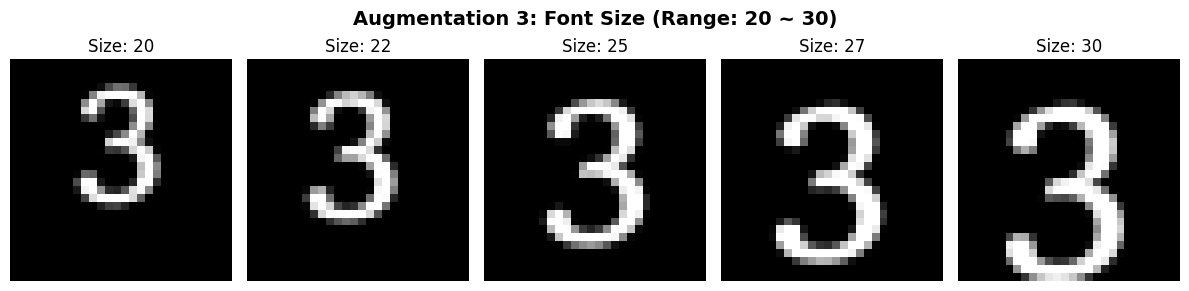

In [21]:
def apply_font_size_variation(digit, font_path, size_range=(18, 32)):
    """
    랜덤 폰트 크기로 숫자를 생성합니다.
    
    Args:
        digit (int): 생성할 숫자
        font_path (str): 폰트 파일 경로
        size_range (tuple): 최소 및 최대 폰트 크기
    
    Returns:
        PIL.Image: 폰트 크기가 변형된 생성된 이미지
    """
    font_size = random.randint(*size_range)
    return generate_base_digit(digit, font_path, font_size=font_size)

# 시각화
if FONT_PATHS:
    test_digit = 3
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 3: Font Size (Range: {FONT_SIZE_RANGE[0]} ~ {FONT_SIZE_RANGE[1]})', 
                 fontsize=14, fontweight='bold')
    
    font_sizes = np.linspace(FONT_SIZE_RANGE[0], FONT_SIZE_RANGE[1], 5, dtype=int)
    
    for i, (ax, font_size) in enumerate(zip(axes, font_sizes)):
        img = generate_base_digit(test_digit, test_font, font_size=font_size)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Size: {font_size}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. 증강 함수 4: 폰트 굵기 변형

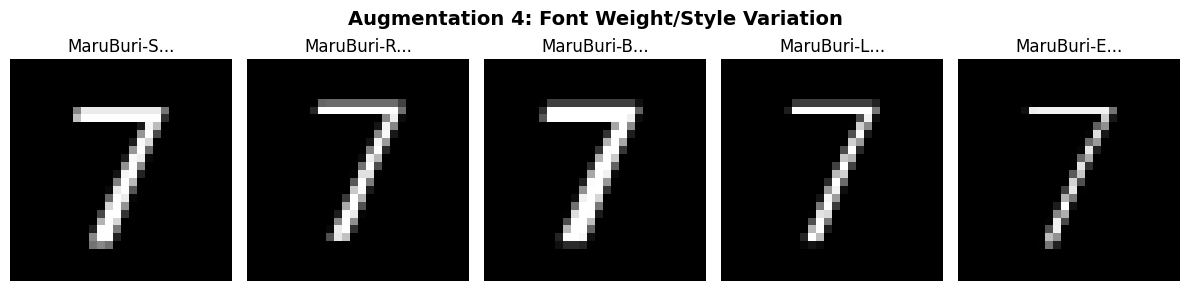

In [22]:
def apply_font_weight_variation(digit, font_paths_list):
    """
    다른 폰트를 사용하여 숫자를 생성합니다 (굵기 변형).
    
    Args:
        digit (int): 생성할 숫자
        font_paths_list (list): 폰트 파일 경로 리스트
    
    Returns:
        PIL.Image: 랜덤 폰트로 생성된 이미지
    """
    font_path = random.choice(font_paths_list)
    return generate_base_digit(digit, font_path)

# 시각화
if len(FONT_PATHS) >= 5:
    test_digit = 7
    sample_fonts = random.sample(FONT_PATHS, min(5, len(FONT_PATHS)))
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle('Augmentation 4: Font Weight/Style Variation', fontsize=14, fontweight='bold')
    
    for i, (ax, font_path) in enumerate(zip(axes, sample_fonts)):
        img = generate_base_digit(test_digit, font_path)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'{os.path.basename(font_path)[:10]}...')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. 증강 함수 5: 위치 변형

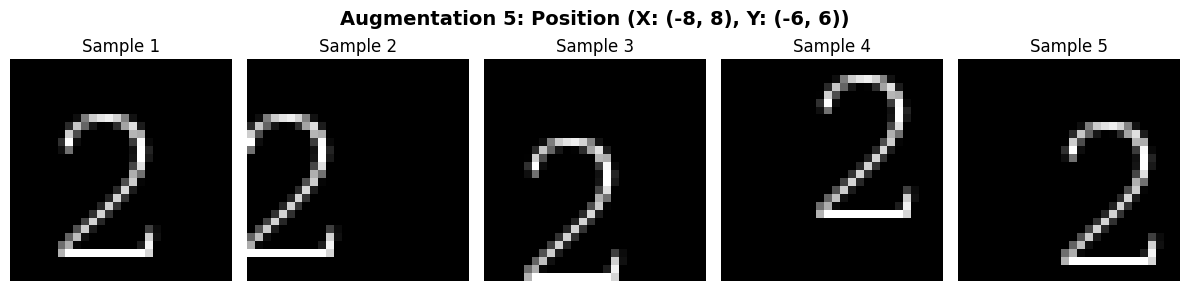

In [23]:
def apply_position_variation(digit, font_path, x_range=(-3, 3), y_range=(-5, 2)):
    """
    랜덤 위치 오프셋으로 숫자를 생성합니다.
    
    Args:
        digit (int): 생성할 숫자
        font_path (str): 폰트 파일 경로
        x_range (tuple): 수평 오프셋 범위
        y_range (tuple): 수직 오프셋 범위
    
    Returns:
        PIL.Image: 위치 오프셋이 적용된 생성된 이미지
    """
    image = Image.new("L", IMAGE_SIZE, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, BASE_FONT_SIZE)
    except IOError:
        return None
    
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # 랜덤 오프셋
    x_offset = random.randint(*x_range)
    y_offset = random.randint(*y_range)
    
    # 위치: 수평 중앙 + x_offset, 수직으로 -3 + y_offset
    position = (
        (IMAGE_SIZE[0] - text_width) // 2 + x_offset,
        -3 + y_offset
    )
    
    draw.text(position, str(digit), fill=0, font=font)
    return image

# 시각화
if FONT_PATHS:
    test_digit = 2
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 5: Position (X: {POSITION_X_RANGE}, Y: {POSITION_Y_RANGE})', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes):
        img = apply_position_variation(test_digit, test_font, x_range=POSITION_X_RANGE, y_range=POSITION_Y_RANGE)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Sample {i+1}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. 증강 함수 6: 색상 변형 (전경/배경 색상)

RGB 3채널 이미지로 변환하여 7가지 무지개 색상을 적용합니다.

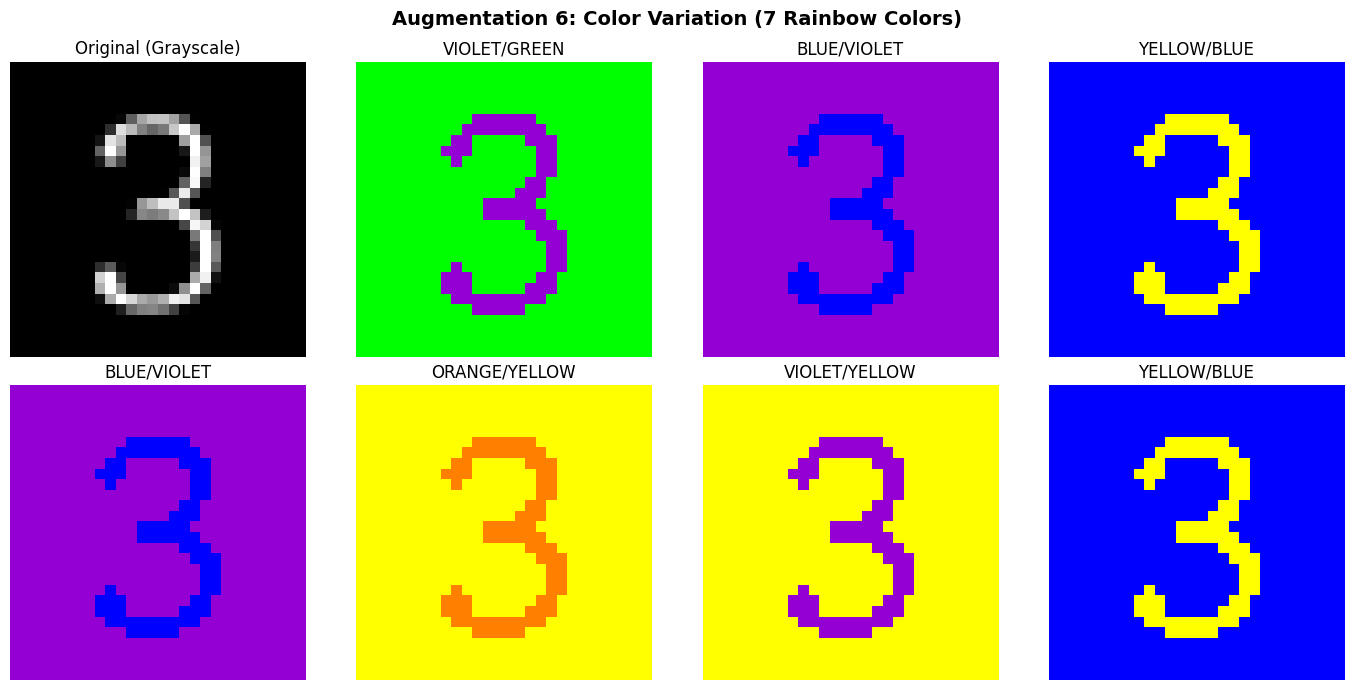

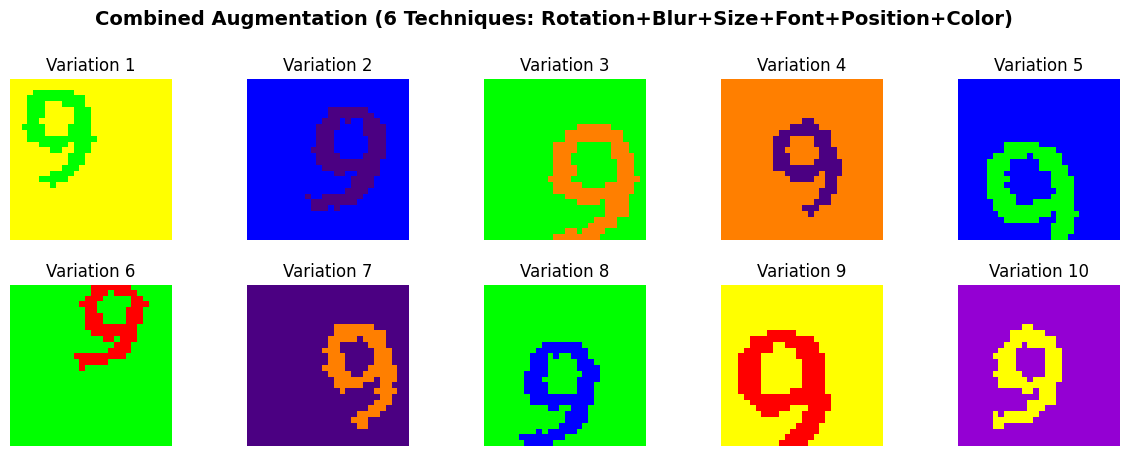

In [24]:
def get_random_rainbow_color():
    """무지개 팔레트에서 임의의 색상을 선택합니다."""
    idx = np.random.randint(0, len(RAINBOW_COLORS))
    return RAINBOW_COLORS[idx], RAINBOW_NAMES[idx]

def colorize_digit_with_threshold(gray_array, fg_color, bg_color, threshold=64):
    """
    그레이스케일 배열에 임계값을 적용하여 경계선 번짐 없이 선명한 전경/배경 색을 적용합니다.
    
    Args:
        gray_array (numpy.ndarray): 그레이스케일 이미지 배열 (28x28)
        fg_color (tuple): 전경 색상 RGB
        bg_color (tuple): 배경 색상 RGB
        threshold (int): 임계값 (기본값: 128)
    
    Returns:
        numpy.ndarray: RGB 색상 이미지 배열 (28x28x3)
    """
    # RGB 이미지 생성 (배경색으로 초기화)
    rgb_image = np.zeros((*gray_array.shape, 3), dtype=np.uint8)
    rgb_image[:, :] = bg_color
    
    # 임계값을 적용하여 마스크 생성
    mask = gray_array > threshold
    
    # 마스크에 해당하는 픽셀을 전경색으로 설정
    rgb_image[mask] = fg_color
    
    return rgb_image

# 시각화 - 색상 증강
if FONT_PATHS:
    test_digit = 3
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Augmentation 6: Color Variation (7 Rainbow Colors)', fontsize=14, fontweight='bold')
    
    axes = axes.flatten()
    
    # 원본 그레이스케일 이미지
    base_img = generate_base_digit(test_digit, test_font)
    if base_img:
        img_array = 255 - np.array(base_img)
        axes[0].imshow(img_array, cmap='gray')
        axes[0].set_title('Original (Grayscale)')
        axes[0].axis('off')
        
        # 7가지 색상 조합 샘플
        for i in range(1, 8):
            # 전경과 배경 색상을 무작위로 선택
            fg_color, fg_label = get_random_rainbow_color()
            bg_color, bg_label = get_random_rainbow_color()
            
            # 전경과 배경 색상이 같지 않도록 보장
            while bg_color == fg_color:
                bg_color, bg_label = get_random_rainbow_color()
            
            # 색상 적용
            colored_img = colorize_digit_with_threshold(img_array, fg_color, bg_color)
            
            axes[i].imshow(colored_img)
            axes[i].set_title(f'{fg_label}/{bg_label}')
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def generate_augmented_digit(digit, font_path, 
                            rotation_range=ROTATION_RANGE,
                            blur_range=BLUR_RADIUS_RANGE,
                            size_range=FONT_SIZE_RANGE,
                            x_range=POSITION_X_RANGE,
                            y_range=POSITION_Y_RANGE):
    """
    모든 변형이 적용된 완전히 증강된 숫자 이미지를 생성합니다 (RGB 색상 포함).
    
    Args:
        digit (int): 생성할 숫자 (0-9)
        font_path (str): 폰트 파일 경로
        rotation_range (tuple): 회전 각도 범위
        blur_range (tuple): 블러 반경 범위
        size_range (tuple): 폰트 크기 범위
        x_range (tuple): 수평 위치 오프셋 범위
        y_range (tuple): 수직 위치 오프셋 범위
    
    Returns:
        numpy.ndarray: 28x28x3 RGB 이미지 배열
    """
    
    # 랜덤 파라미터
    font_size = random.randint(*size_range)
    rotation_angle = random.uniform(*rotation_range)
    blur_radius = random.uniform(*blur_range)
    x_offset = random.randint(*x_range)
    y_offset = random.randint(*y_range)
    
    # 회전을 위한 더 큰 캔버스 생성
    canvas_size = (40, 40)
    image = Image.new("L", canvas_size, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        return None
    
    # 오프셋이 적용된 중앙 위치 계산
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # 위치: 수평 중앙 + x_offset, 수직으로 3 + y_offset
    position = (
        (canvas_size[0] - text_width) // 2 + x_offset,
        3 + y_offset
    )
    
    # 텍스트 그리기
    draw.text(position, str(digit), fill=0, font=font)
    
    # 회전 적용
    if abs(rotation_angle) > 0.1:
        image = image.rotate(rotation_angle, fillcolor=255, expand=False)
    
    # 블러 적용
    if blur_radius > 0.1:
        image = image.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    
    # 28x28로 자르기
    left = (canvas_size[0] - IMAGE_SIZE[0]) // 2
    top = (canvas_size[1] - IMAGE_SIZE[1]) // 2
    image = image.crop((left, top, left + IMAGE_SIZE[0], top + IMAGE_SIZE[1]))
    
    # numpy 배열로 변환 및 반전
    image_array = np.array(image)
    image_array = 255 - image_array
    
    # 색상 적용
    fg_color, _ = get_random_rainbow_color()
    bg_color, _ = get_random_rainbow_color()
    
    # 전경과 배경 색상이 같지 않도록 보장
    while bg_color == fg_color:
        bg_color, _ = get_random_rainbow_color()
    
    # RGB 이미지로 변환
    rgb_image = colorize_digit_with_threshold(image_array, fg_color, bg_color)
    
    return rgb_image

# 시각화 - 결합 증강 (색상 포함)
if FONT_PATHS:
    test_digit = 9
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('Combined Augmentation (6 Techniques: Rotation+Blur+Size+Font+Position+Color)', fontsize=14, fontweight='bold')

    axes = axes.flatten()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    for i, ax in enumerate(axes):
        ax.axis('off')
        img_array = generate_augmented_digit(test_digit, test_font)
        if img_array is not None:
            ax.imshow(img_array)
        ax.set_title(f'Variation {i+1}')

    plt.show()

## 9. 완전한 데이터셋 생성

In [ ]:
def generate_complete_dataset(variations_per_digit=VARIATIONS_PER_DIGIT):
    """
    완전한 증강 MNIST 데이터셋을 생성합니다 (RGB 색상 포함).
    
    Args:
        variations_per_digit (int): 숫자당 폰트당 변형 개수
    
    Returns:
        tuple: (images, labels) numpy 배열
        - images: (N, 28, 28, 3) RGB 이미지
        - labels: (N,) 레이블
    """
    if not FONT_PATHS:
        raise ValueError("폰트 파일을 찾을 수 없습니다!")
    
    total_images = len(FONT_PATHS) * 10 * variations_per_digit
    print(f"{total_images}개의 이미지를 생성합니다...")
    print(f"  - 폰트: {len(FONT_PATHS)}")
    print(f"  - 폰트당 숫자: 10 (0-9)")
    print(f"  - 숫자당 변형: {variations_per_digit}")
    print(f"  - 색상: RGB 3채널 (7가지 무지개 색상 조합)")
    
    images_list = []
    labels_list = []
    rejected_count = 0
    max_attempts = 20  # 유효한 이미지 생성을 위한 최대 시도 횟수
    
    for font_idx, font_path in enumerate(tqdm(FONT_PATHS, desc="폰트 처리 중")):
        for digit in range(10):
            for variation in range(variations_per_digit):
                # 유효한 이미지 생성 시도 (바운딩 박스가 28x28 내부에 있어야 함)
                for attempt in range(max_attempts):
                    image = generate_augmented_digit(digit, font_path)
                    
                    if image is None:
                        continue
                    
                    # RGB 이미지를 그레이스케일로 변환하여 바운딩 박스 계산
                    gray_image = np.mean(image, axis=2).astype(np.uint8)
                    
                    # 각 행과 열에서 모든 값이 동일한지 확인 (숫자가 없는 줄 감지)
                    # 행(row)별로 검사: 모든 값이 같으면 해당 행에는 숫자가 없음
                    rows_with_digit = []
                    for i in range(gray_image.shape[0]):
                        row = gray_image[i, :]
                        # 행의 모든 값이 같지 않으면 숫자가 있는 행
                        if not np.all(row == row[0]):
                            rows_with_digit.append(i)
                    
                    # 열(col)별로 검사: 모든 값이 같으면 해당 열에는 숫자가 없음
                    cols_with_digit = []
                    for j in range(gray_image.shape[1]):
                        col = gray_image[:, j]
                        # 열의 모든 값이 같지 않으면 숫자가 있는 열
                        if not np.all(col == col[0]):
                            cols_with_digit.append(j)
                    
                    # 숫자가 있는 행과 열이 없으면 무효한 이미지
                    if len(rows_with_digit) == 0 or len(cols_with_digit) == 0:
                        continue
                    
                    # 바운딩 박스 가져오기
                    row_min = rows_with_digit[0]
                    row_max = rows_with_digit[-1]
                    col_min = cols_with_digit[0]
                    col_max = cols_with_digit[-1]
                    
                    # 바운딩 박스가 이미지 내부에 완전히 포함되는지 확인 (여백 포함)
                    margin = 1  # 가장자리로부터 1픽셀 여백 허용
                    if (row_min >= margin and row_max < IMAGE_SIZE[1] - margin and
                        col_min >= margin and col_max < IMAGE_SIZE[0] - margin):
                        # 유효한 이미지 - 숫자가 완전히 포함됨
                        images_list.append(image)
                        labels_list.append(digit)
                        break
                else:
                    rejected_count += 1
    
    images = np.array(images_list, dtype=np.uint8)
    labels = np.array(labels_list, dtype=np.uint8)
    
    print(f"\n✓ 생성 완료!")
    print(f"  전체 이미지: {len(images)}")
    print(f"  거부됨 (경계 벗어남): {rejected_count}")
    print(f"  성공률: {len(images)/(len(images)+rejected_count)*100:.1f}%")
    print(f"  이미지 크기: {images.shape}")
    print(f"  레이블 크기: {labels.shape}")
    
    return images, labels


In [26]:
# 설정된 파라미터를 사용하여 데이터셋 생성
images, labels = generate_complete_dataset()

150개의 이미지를 생성합니다...
  - 폰트: 5
  - 폰트당 숫자: 10 (0-9)
  - 숫자당 변형: 3
  - 색상: RGB 3채널 (7가지 무지개 색상 조합)


폰트 처리 중: 100%|██████████| 5/5 [00:00<00:00, 25.04it/s]



✓ 생성 완료!
  전체 이미지: 150
  거부됨 (경계 벗어남): 0
  성공률: 100.0%
  이미지 크기: (150, 28, 28, 3)
  레이블 크기: (150,)


## 10. 데이터셋 샘플 시각화

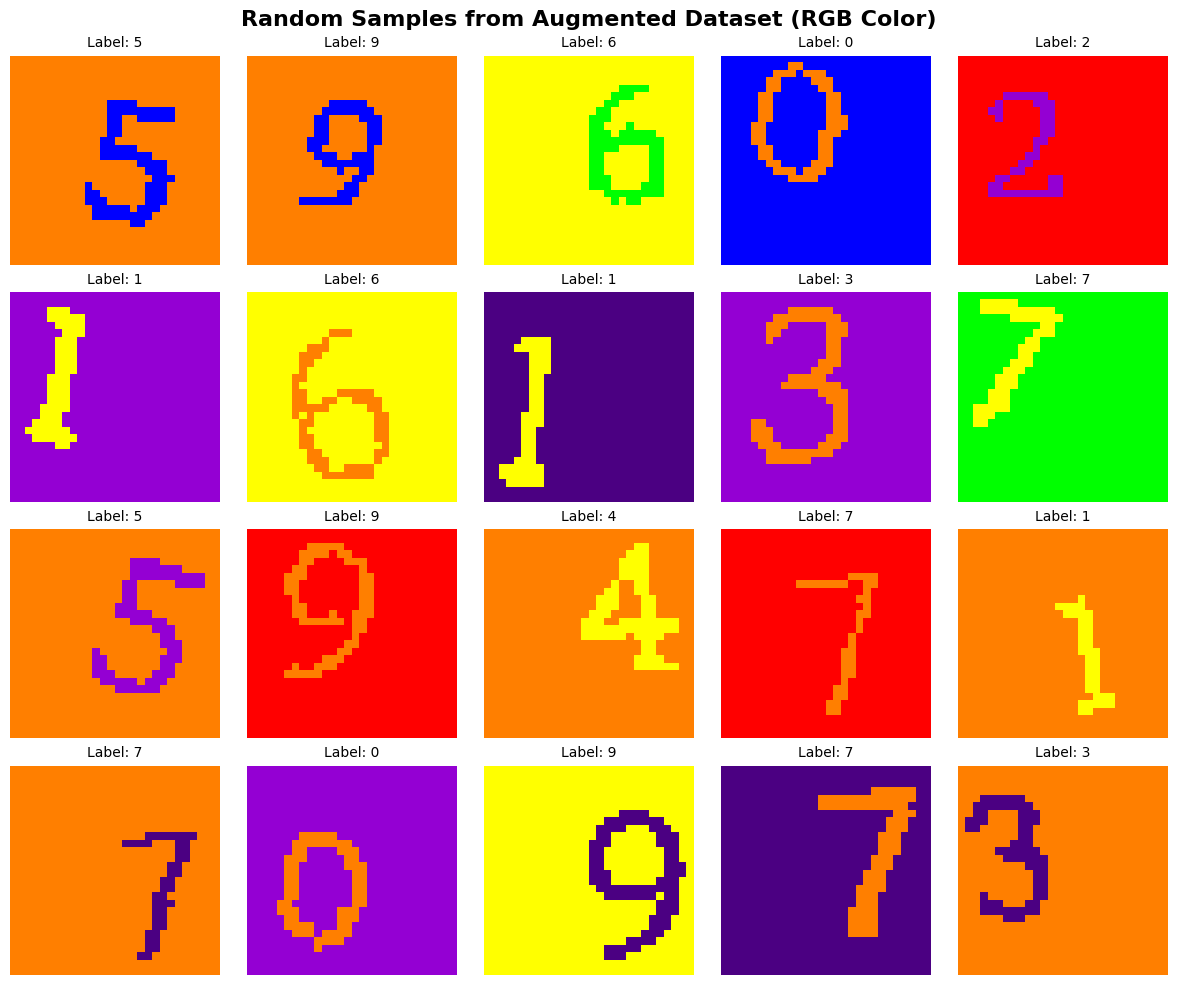

In [27]:
# 생성된 데이터셋에서 랜덤 샘플 표시
num_samples = 20
indices = random.sample(range(len(images)), num_samples)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('Random Samples from Augmented Dataset (RGB Color)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img_idx = indices[idx]
    ax.imshow(images[img_idx])  # RGB 이미지이므로 cmap 불필요
    ax.set_title(f'Label: {labels[img_idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. 데이터셋 통계

데이터셋 통계
숫자 0:    15 이미지 (10.0%)
숫자 1:    15 이미지 (10.0%)
숫자 2:    15 이미지 (10.0%)
숫자 3:    15 이미지 (10.0%)
숫자 4:    15 이미지 (10.0%)
숫자 5:    15 이미지 (10.0%)
숫자 6:    15 이미지 (10.0%)
숫자 7:    15 이미지 (10.0%)
숫자 8:    15 이미지 (10.0%)
숫자 9:    15 이미지 (10.0%)
전체: 150 이미지


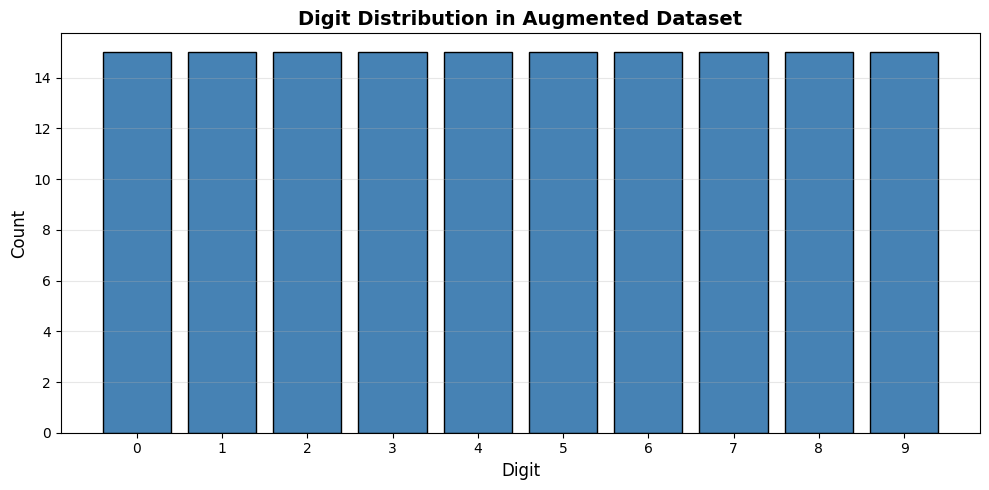

In [28]:
# 데이터셋 통계 출력
print("=" * 50)
print("데이터셋 통계")
print("=" * 50)

for digit in range(10):
    count = np.sum(labels == digit)
    percentage = (count / len(labels)) * 100
    print(f"숫자 {digit}: {count:5d} 이미지 ({percentage:.1f}%)")

print("=" * 50)
print(f"전체: {len(labels)} 이미지")

# 분포 시각화
plt.figure(figsize=(10, 5))
digit_counts = [np.sum(labels == i) for i in range(10)]
plt.bar(range(10), digit_counts, color='steelblue', edgecolor='black')
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Digit Distribution in Augmented Dataset', fontsize=14, fontweight='bold')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. 데이터셋을 .npz 파일로 저장

In [29]:
output_path = '../assets/mnist_aug_color.npz'

np.savez_compressed(
    output_path,
    train_images=images,
    train_labels=labels
)

file_size_mb = os.path.getsize(output_path) / 1024 / 1024

print("=" * 50)
print("✓ 데이터셋 저장 완료!")
print("=" * 50)
print(f"파일 경로: {output_path}")
print(f"파일 크기: {file_size_mb:.2f} MB")
print(f"이미지: {images.shape} (RGB 3채널)")
print(f"레이블: {labels.shape}")
print("=" * 50)

✓ 데이터셋 저장 완료!
파일 경로: ../assets/mnist_aug_color.npz
파일 크기: 0.01 MB
이미지: (150, 28, 28, 3) (RGB 3채널)
레이블: (150,)


## 13. 저장된 데이터셋 검증

저장된 파일의 키: ['train_images', 'train_labels']

로드된 이미지 크기: (150, 28, 28, 3)
로드된 레이블 크기: (150,)


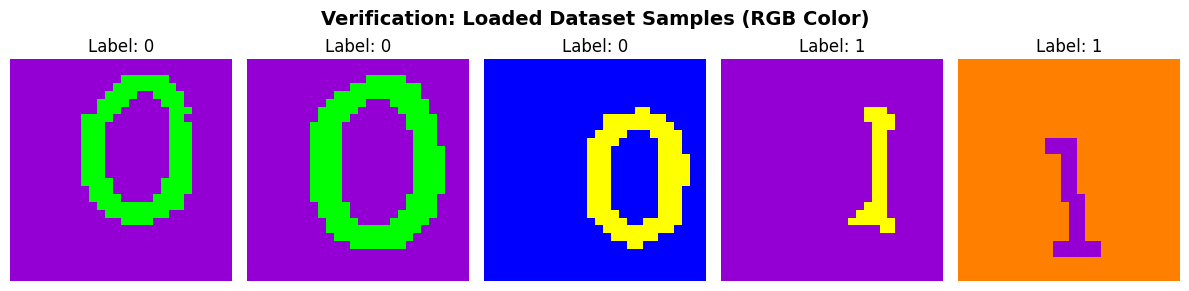


✓ 데이터셋 검증 완료!


In [30]:
# 저장된 데이터셋 로드 및 검증
loaded_data = np.load(output_path)

print("저장된 파일의 키:", list(loaded_data.keys()))
print(f"\n로드된 이미지 크기: {loaded_data['train_images'].shape}")
print(f"로드된 레이블 크기: {loaded_data['train_labels'].shape}")

# 로드된 데이터에서 몇 가지 샘플 표시
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('Verification: Loaded Dataset Samples (RGB Color)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    ax.imshow(loaded_data['train_images'][i])  # RGB 이미지
    ax.set_title(f"Label: {loaded_data['train_labels'][i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ 데이터셋 검증 완료!")